In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 500 * 10**5 # In timesteps of dt
gridpoints = 128 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

length_a = 16
length_b = 20

B2 = 2190 # Units: nm^3

print("Fin")

Fin


In [8]:
# Initializes array of density values
np.random.seed(7) # Opens a random number generator instance, seed 7


rho = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=gridpoints)) # Creates rho values around the mean with slight randomness
rho = np.maximum(rho, 1.E-10)  # Prevents negative densities

initial_mass = np.sum(rho)

Ts = np.arange(290.15,310.15, 1)
rho_min_max = (1.E-9,32.E-4)
drho = 1.E-8
rhoAs = np.arange(rho_min_max[0],rho_min_max[1],drho)



# AAAA by itself
type = "AAAA"

# Finds chemical potential of reference system
def murel(rhoA):
    return np.log(rhoA)+2*B2*rhoA

# Finds chemical potential from bonding
def mubond(rhoA, Da, Db):
    x = 4*Da*rhoA
    Xa = (-1+np.sqrt(1+4*x))/(2*x)
    return 4*np.log(Xa)

# Finds total chemical potential
def f(rho, Da, Db):
    return murel(rho)+mubond(rho, Da, Db)


'''

# ABBB by itself
type = "ABBB"

# Finds chemical potential of reference system
def murel(rho):
    return np.log(rho)+2*B2*rho

# Finds chemical potential from bonding
def mubond(rho, Da, Db):
    Ca = 0.25 * 4*Da*rho
    Cb = 0.75 * 4*Db*rho
    Xa = (-1+np.sqrt(1+4*Ca))/(2*Ca)
    Xb = (-1+np.sqrt(1+4*Cb))/(2*Cb)
    return ((4/4)*(np.log(Xa)+3*np.log(Xb)))

# Finds total chemical potential
def f(rho):
    return murel(rho)+mubond(rho, Da, Db)

'''

# Finds the rho values at which the chemical potential equals a value h
def find_roots_for_h(f, Da, Db, h, rho_range, num_points=1000):
    def shifted_function(x):
        return f(x, Da, Db) - h  # search the solution for f(x) - h = 0 
    
    x = np.linspace(rho_range[0], rho_range[1], num_points)
    roots = []
    for i in range(len(x) - 1):
        if shifted_function(x[i]) * shifted_function(x[i + 1]) < 0:
            res = root_scalar(shifted_function, bracket=[x[i], x[i + 1]], method='brentq')
            roots.append(res.root)
    return np.array(roots)



num_data = 100

def df_numeric(f, Da, Db, rho, h=1e-8):
    return ((f(rho + h, Da, Db) - f(rho - h, Da, Db)) / (2 * h))

B2_values = [1000, 1500, 2000, 2500, 3000] #NOTE: Even for asymmetric nanostars this is the single B2 value of the nanostar with itself!!

A_dH_values = [-38000, -38000, -38000, -38000, -38000]
A_dS_values = [-110, -110, -110, -110, -110]

B_dH_values = [-38000, -38000, -38000, -38000, -38000]
B_dS_values = [-110, -110, -110, -110, -110]



for index in range(len(B2_values)):
    binodals=[]
    B2 = B2_values[index]

    for T in Ts:
    
        '''Calculates the concentrations that correspond
        to the dilute and dense phase for each valence  
        as a function of the temperature of the system'''

        print(f"index= {index} out of {len(A_dH_values)} and T= {T}")

        Da = vb*np.exp(-(A_dH_values[index]-T*(A_dS_values[index]))/(mol*kB*T))  
        Db = vb*np.exp(-(B_dH_values[index]-T*(B_dS_values[index]))/(mol*kB*T))  
        x = rhoAs
        

        h_min=find_peaks(-f(x, Da, Db))[0]
        h_max=find_peaks(f(x, Da, Db))[0]

        # check if f has minima and maxima
        if(len(h_min)==1 and len(h_max)==1):
            h_min = f(x, Da, Db)[h_min[0]]
            h_max = f(x, Da, Db)[h_max[0]]
            hs=np.linspace(h_min,h_max,num_data)

# find binodal
            results = []
            for h in hs:
                roots = find_roots_for_h(f, Da, Db, h, rho_min_max)
                if len(roots) > 2:
                    def function(x):
                        return f(x, Da, Db)
                    x1, x3 = roots[0], roots[-1]
                    integral, _ = quad(function, x1, x3)
                    results.append([h, x1, x3, integral - function(x1) * (x3 - x1)])
            results = np.array(results)
            if results.size == 0:
                continue
            _, c1, c2, _ = results[((results.T[3])**2).argmin()]
            binodals.append([T, c1, c2])
        

    binodals = np.array(binodals)
    os.makedirs('binodals', exist_ok=True)
    path = os.path.join('binodals', 'dGbinodals')
    os.makedirs(path, exist_ok=True)
    if binodals.size > 0:
        np.savetxt(f'binodals/dGbinodals/B2 {B2} AdH{A_dH_values[index]} AdS{A_dS_values[index]} BdH{B_dH_values[index]} BdS{B_dS_values[index]}', binodals, header="T, c1, c2")
    print(B2)

index= 0 out of 5 and T= 290.15
index= 0 out of 5 and T= 291.15
index= 0 out of 5 and T= 292.15
index= 0 out of 5 and T= 293.15
index= 0 out of 5 and T= 294.15
index= 0 out of 5 and T= 295.15
index= 0 out of 5 and T= 296.15
index= 0 out of 5 and T= 297.15
index= 0 out of 5 and T= 298.15
index= 0 out of 5 and T= 299.15
index= 0 out of 5 and T= 300.15
index= 0 out of 5 and T= 301.15
index= 0 out of 5 and T= 302.15
index= 0 out of 5 and T= 303.15
index= 0 out of 5 and T= 304.15
index= 0 out of 5 and T= 305.15
index= 0 out of 5 and T= 306.15
index= 0 out of 5 and T= 307.15
index= 0 out of 5 and T= 308.15
index= 0 out of 5 and T= 309.15
1000
index= 1 out of 5 and T= 290.15
index= 1 out of 5 and T= 291.15
index= 1 out of 5 and T= 292.15
index= 1 out of 5 and T= 293.15
index= 1 out of 5 and T= 294.15
index= 1 out of 5 and T= 295.15
index= 1 out of 5 and T= 296.15
index= 1 out of 5 and T= 297.15
index= 1 out of 5 and T= 298.15
index= 1 out of 5 and T= 299.15
index= 1 out of 5 and T= 300.15
ind

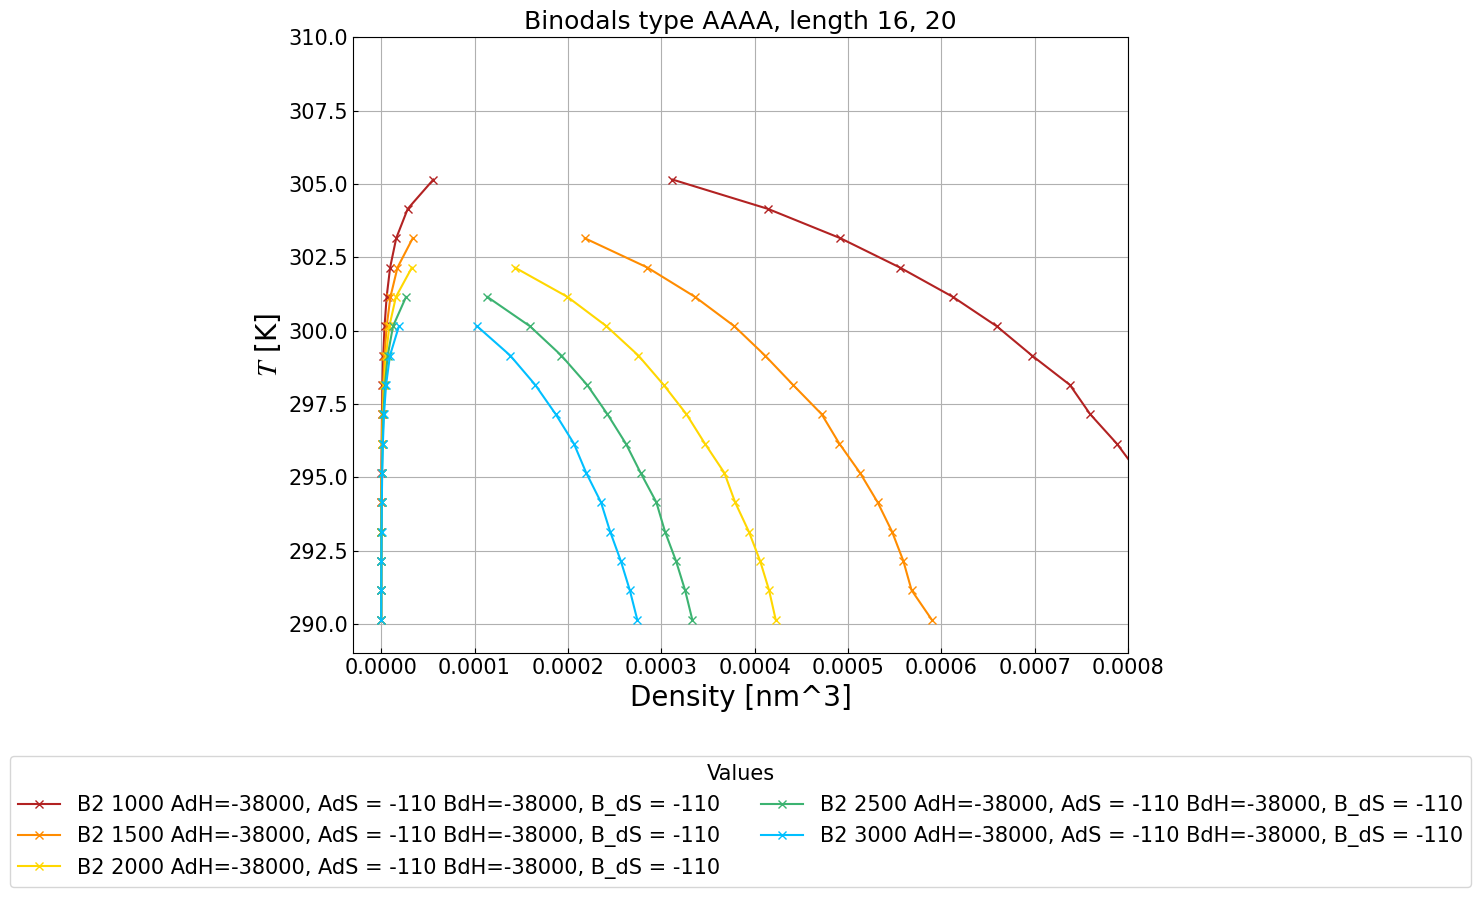

In [10]:
# Sets fonts and that sort of stuff for the plot
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams["font.size"] = 15 
plt.rcParams['xtick.labelsize'] = 15 
plt.rcParams['ytick.labelsize'] = 15 
plt.figure(figsize = (10, 8))


# Plots the data
colors = ["firebrick", "darkorange", "gold", "mediumseagreen", "deepskyblue", "royalblue", "darkorchid", "deeppink", "chocolate"]


for index in range(len(B2_values)):
    fname = f'binodals/dGbinodals/B2 {B2_values[index]} AdH{A_dH_values[index]} AdS{A_dS_values[index]} BdH{B_dH_values[index]} BdS{B_dS_values[index]}'
    if not os.path.exists(fname):
        print(f"Missing: {fname}")
        continue
    data = np.loadtxt(fname)
    plt.plot(data.T[1], data.T[0], 'x-', label=f"B2 {B2_values[index]} AdH={A_dH_values[index]}, AdS = {A_dS_values[index]} BdH={B_dH_values[index]}, B_dS = {B_dS_values[index]}", color = colors[index ])
    plt.plot(data.T[2], data.T[0] , 'x-', color = colors[index])


# Save to directory
os.makedirs('binodals/dGbinodals/Results', exist_ok=True)

# Plot upkeep etc
plt.title(f"Binodals type {type}, length {length_a}, {length_b}")
plt.xlabel("Density [nm^3]", fontsize=20)
plt.ylabel("$T$ [K]",fontsize=20)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, title="Values")
plt.xlim(-0.00003, 0.00080)
plt.ylim(289, 310)
plt.grid(which= "both")
plt.tick_params(axis='x', which="both", direction='in')
plt.tick_params(axis='y', which="both", direction='in')      
plt.savefig(f"type_{type}_a_{length_a}_b_{length_b}.png")